# Embalses
***

In [9]:
from pathlib import Path

# import numpy as np
import pandas as pd
import geopandas as gpd
import rioxarray as rxr
import pyflwdir
import yaml
from tqdm import tqdm

from camels_es.config import Config
from camels_es.anuario_aforos import extraer_embalses
from camels_es.plots import plot_stations
from camels_es.basins.utils import create_input_csv

## Configuration

In [4]:
cfg = Config('../config_BEAVER.yml')

In [17]:
# configure paths
path_gdw = Path('/mnt/c/Datasets/reservoirs/GDW/GDW_v1_0_shp')
path_snczi = Path('/mnt/c/Datasets/CEDEX/processed/reservoirs/attributes/GIS')

## Data

In [5]:
# identificar demarcaciones hidrográficas
cuencas = {dir.stem: dir for dir in cfg.path_records.iterdir() if dir.is_dir() &  (dir.stem not in ['estaciones', 'GIS', 'timeseries'])}

### Anuario de Aforos

Leyendo embalses de: /home/casadoj/Data/BEAVER-ES/v1_0_0/GIS/embalses.geojson

nº total de embalses:			398
nº de embalses en servicio:		367


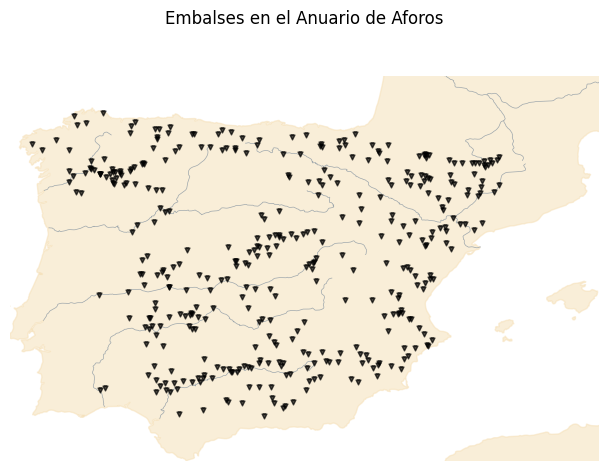

In [6]:
file_reservoirs = cfg.path_gis / 'embalses.geojson'
file_mapping = cfg.path_gis / 'embalses_codigos.yml'
if file_reservoirs.is_file():
    print(f'Leyendo embalses de: {file_reservoirs}')

    # cargar capa de embalses
    embalses = gpd.read_file(file_reservoirs).set_index('ref_ceh')
    embalses.index = embalses.index.astype(int)

else:
    # extraer embalses del Anuario de Aforos
    embalses = []
    for cuenca in tqdm(cuencas):
        res = extraer_embalses(cfg.path_records / cuenca / 'embalse.csv', epsg=cfg.crs)
        res['cuenca'] = cuenca
        embalses.append(res)
        print('nº de embalses en el {0:>13}:\t{1:>3}'.format(cuenca.title(), res.shape[0]))
        del res
    embalses = pd.concat(embalses, axis=0)

    # cargar correspondencia de códigos de embalse
    if file_mapping.is_file():
        # leer archivo
        with open(file_mapping, 'r') as file:
            mapping_reservoirs = yaml.safe_load(file)
        # añadir códigos
        cols = ['SNCZI', 'GDW_ID']
        for col in cols:
            embalses[col] = embalses.index.map({ID: dct[col] for ID, dct in mapping_reservoirs.items()})
        embalses[cols] = embalses[cols].astype('Int64')

    # Export
    embalses.sort_index(axis=0, inplace=True)
    embalses.to_file(file_reservoirs, driver='GeoJSON')
    print(f'Los embalses se han guardado en: {file_reservoirs}')
    
# mapa de los embalses
plot_stations(
    embalses.geometry, 
    # area=estaciones.suprest, 
    extent=[-9.5, 3.5, 36, 44.5],
    marker='v',
    color='k',
    title=f'Embalses en el Anuario de Aforos',
    # save=cfg.path_plots / 'embalses.jpg'
)

print('\nnº total de embalses:\t\t\t{0:>3}'.format(embalses.shape[0]))
print('nº de embalses en servicio:\t\t{0:>3}'.format(embalses.loc[embalses.serv == 1].shape[0]))

### SNCZI

In [11]:
# load reservoirs
egis_embalse = gpd.read_file(path_snczi / 'egis_embalse.shp').set_index('CODIGO')
egis_embalse.index.name = 'SNCZI'
print(f'No. reservoirs:\t{len(egis_embalse)}')

# load dams
egis_presa = gpd.read_file(path_snczi / 'egis_presa.shp')#.set_index('CODIGO')
# egis_presa.index.name = 'SNCZI'
print(f'No. dams:\t{len(egis_presa)}')

No. reservoirs:	3170
No. dams:	3208


Hay más presas que embalses.

### GDW

In [18]:
# load reservoirs
gdw_reservoirs = gpd.read_file(path_gdw / 'GDW_reservoirs_v1_0.shp').set_index('GDW_ID')
# gdw_reservoirs = gdw_reservoirs[gdw_reservoirs.COUNTRY.str.lower() == 'spain']
print(f'No. reservoirs:\t{len(gdw_reservoirs)}')

# load dams
gdw_barriers = gpd.read_file(path_gdw / 'GDW_barriers_v1_0.shp').set_index('GDW_ID')
# gdw_barriers = gdw_barriers[gdw_barriers.COUNTRY.str.lower() == 'spain']
print(f'No. dams:\t{len(gdw_barriers)}')

No. reservoirs:	35295
No. dams:	41145


In [11]:
gdw_reservoirs.index.intersection(embalses.GDW_ID)

Index([ 1405.0,  1407.0,  1408.0,  1409.0,  1410.0,  1411.0,  1422.0,  1423.0,
        1430.0,  1433.0,
       ...
       35780.0, 35783.0, 35789.0, 35793.0, 35796.0, 35804.0, 35822.0, 37330.0,
       37334.0, 37355.0],
      dtype='float64', name='GDW_ID', length=306)

Hay menos embalses que presas en GDW, lo que puede tener sentido puesto que hay embalses con más de una presa. Sin embargo, cuando se cruzan los datos con los del Anuario de Aforos, hay 313 presas de GDW que coinciden con un embalse del Anuario, pero 305 embalses.

***

#### `basin-delineation`

En esta sección creo el CSV de entrada para localizar los embalses en el MDT de MERIT y EFAS. Como el _Anuario de Aforos_ no incluye el área de la cuenca de los embalses, lo tengo que extraer bien del _Sistema Nacional de Caracterización de Zonas Inundables_ (SNCZI) o del _Global Dam Watch_ (GDW), dado que los datos del SNCZI son erróneos a menudo.

No todos los embalses en el _Anuario de Aforos_ tienen el dato del área de cuenca, con lo que no pueden localizarse automáticamente en los MDT.

> **¡PRECAUCIÓN!** La capa de embalses/presas del SNCZI contiene muchos más embalses que los del _Anuario de Aforos_. ¿Convendría localizar todos ellos en los MDT para calcular el grado de alteración de las estaciones de aforo en CAMELS-ES?

In [19]:
# Extract catchment area from SNCZI
area_snczi = egis_embalse.loc[embalses.SNCZI.dropna(), 'SUP_CUENCA'].dropna()
area_snczi.name = 'SNCZI'

# Remap index to the ID in "Anuario de Aforos"
map_snczi_aa = {int(snczi_id): aa_id for aa_id, snczi_id in embalses.SNCZI.items() if pd.notnull(snczi_id)}
area_snczi.index = pd.Series(
    area_snczi.index.map(map_snczi_aa),
    name=embalses.index.name
)

# Extract catchment area from GDW
area_gdw = gdw_barriers.loc[embalses.GDW_ID.dropna(), 'CATCH_SKM'].dropna()
area_gdw.name = 'GDW'

# Remap index to the ID in "Anuario de Aforos"
map_gdw_aa = {int(gdw_id): aa_id for aa_id, gdw_id in embalses.GDW_ID.items() if pd.notnull(gdw_id)}
area_gdw.index = pd.Series(
    area_gdw.index.map(map_gdw_aa),
    name=embalses.index.name
)

# Select best value: GDW if available, otherwise SNCZI
area = pd.concat([area_snczi, area_gdw], axis=1)
area['CATCH_SKM'] = area.GDW
missing = area.GDW.isnull()
area.loc[missing, 'CATCH_SKM'] = area.loc[missing, 'SNCZI']

# Export CSV file
csv_file = cfg.path_dataset / 'preprocessing/basins/dams.csv'
ids = area[area['CATCH_SKM'] >= cfg.area_min].index
create_input_csv(
    embalses.loc[ids, 'geometry'], 
    area.loc[ids, 'CATCH_SKM'], 
    file=csv_file
)